In [670]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,root_mean_squared_error
import matplotlib.pyplot as plt

In [671]:
TEST_SIZE = 0.2
RANDOM_STATE = 43

In [672]:
df = pd.read_csv('data/games_list.csv')
# df = df.sort_values(by='avg_concurrent_players_after_90',ascending=True).iloc[10:]
df.head(10)


,name,slug,appid,release_date,total_reviews,followers,review_score,avg_playtime,copies_sold,revenue,...,owners,peak_concurrent_players_after_90,peak_concurrent_players_timestamp,avg_concurrent_players_after_90,estimated_launch_reviews,estimated_launch_followers,estimated_launch_copies_sold,developer,publisher,avg_sentiment
0,Half-Life 2,half_life_2,220,2007-10-10,188867.0,100203.0,98.0,11.983311,12989871.0,4.936640e+07,...,24298922.0,2863.0,2008-10-19 00:00:00,1630.256410,18886.7,10020.3,1298987.1,Valve,Valve,0.453232
1,Half-Life 2: Deathmatch,half_life_2_deathmatch,320,2004-11-01,9838.0,9742.0,91.0,8.395212,4586291.0,8.155143e+04,...,17733782.0,2658.0,2008-10-19 00:00:00,1517.717949,983.8,974.2,458629.1,Valve,Valve,0.195170
2,Half-Life Deathmatch: Source,half_life_deathmatch_source,360,2006-05-01,4121.0,6927.0,75.0,3.028733,263669.0,9.867970e+05,...,15424457.0,34.0,2006-08-27 00:00:00,31.000000,412.1,692.7,26366.9,Valve,Valve,0.409477
3,Left 4 Dead 2,left_4_dead_2,550,2009-11-16,766898.0,1253253.0,98.0,31.895563,67102849.0,4.072304e+08,...,93325120.0,28106.0,2009-12-05 00:00:00,16186.000000,76689.8,125325.3,6710284.9,Valve,Valve,0.415017
4,Counter-Strike 2,counter_strike_2,730,2012-08-21,9207275.0,4608883.0,86.0,203.234487,328468834.0,1.030954e+10,...,394713564.0,50533.0,2012-11-01 00:00:00,24538.010989,920727.5,460888.3,32846883.4,Valve,Valve,0.192067
5,BioShock,bioshock,7670,2007-08-21,24493.0,34665.0,94.0,6.269296,1838099.0,1.452727e+07,...,9592672.0,179.0,2008-10-25 00:00:00,84.230769,2449.3,3466.5,183809.9,2K Boston,2K,0.471804
6,Just Cause 2,just_cause_2,8190,2010-03-23,40533.0,57813.0,91.0,12.915710,6020554.0,3.692262e+07,...,10057774.0,3435.0,2010-03-27 00:00:00,1804.164835,4053.3,5781.3,602055.4,Avalanche Studios,Square Enix,0.365690
7,BioShock 2,bioshock_2,8850,2010-02-09,11155.0,32063.0,89.0,6.874669,1023359.0,7.118592e+06,...,10126792.0,4635.0,2010-02-10 00:00:00,485.166667,1115.5,3206.3,102335.9,2K Marin,2K,0.538966
8,BioShock Infinite,bioshock_infinite,8870,2013-03-25,107327.0,131232.0,94.0,12.500227,7134022.0,6.180716e+07,...,12750511.0,65332.0,2013-03-26 00:00:00,8861.857143,10732.7,13123.2,713402.2,Irrational Games,2K,0.476654
9,Saints Row 2,saints_row_2,9480,2009-01-07,12200.0,20253.0,76.0,12.394984,1036729.0,3.971797e+06,...,6732730.0,716.0,2009-02-14 00:00:00,282.739130,1220.0,2025.3,103672.9,Volition,Deep Silver,0.492883


In [673]:

df['log_estimated_launch_copies'] = np.log1p(df['estimated_launch_copies_sold'])
df['log_estimated_launch_reviews'] = np.log1p(df['estimated_launch_reviews'])
df['log_estimated_launch_followers'] = np.log1p(df['estimated_launch_followers'])
df['log_avg_playtime'] = np.log1p(df['avg_playtime'])
df['log_review_score'] = np.log1p(df['review_score'])
df['log_avg_concurrent_players_after_90'] = np.log1p(df['avg_concurrent_players_after_90'])


# Log calculations 
df['log_review_to_follower_ratio'] = df['log_estimated_launch_reviews'] - df['log_estimated_launch_followers']
df['log_copies_to_follower_ratio'] = df['log_estimated_launch_copies'] - df['log_estimated_launch_followers']
# ratios for logs are subtraction due to the rules of logs log(a/b) = log(a) - log(b)
df['log_engagement_quality'] = df['log_avg_playtime'] + df['log_review_score']
# log (a*b) = log(a) + log(b)
df['log_virality_factor'] = df['log_review_to_follower_ratio'] + df['log_review_score']

# features we want to train on
features = [
    'log_estimated_launch_copies',
    'log_review_to_follower_ratio',
    'log_copies_to_follower_ratio',
    'log_engagement_quality',
    'log_virality_factor',
    'log_review_score',
    'avg_sentiment'
]





In [674]:
X = df[features]
y = df['log_avg_concurrent_players_after_90']
X.head(1)

,log_estimated_launch_copies,log_review_to_follower_ratio,log_copies_to_follower_ratio,log_engagement_quality,log_virality_factor,log_review_score,avg_sentiment
0,14.077096,0.633798,4.864628,7.158785,5.228918,4.59512,0.453232


In [675]:
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=TEST_SIZE,random_state=RANDOM_STATE)

In [692]:
# standard random forest without any settings changed
random_forest_base = RandomForestRegressor(n_estimators=100,max_features=1/3,oob_score=True, random_state=RANDOM_STATE)
random_forest_base.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,0.3333333333333333
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [677]:
y_pred_log = random_forest_base.predict(X_test)

In [678]:
mean_absolute_error(y_test, y_pred_log)

0.885267313276846

In [679]:
y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(y_pred_log)
mean_absolute_error(y_test_orig,y_pred_orig)

2414.7278029296294

In [680]:
root_mean_squared_error(y_test_orig,y_pred_orig)

4014.441626012849

In [681]:
r2_score(y_test_orig,y_pred_orig)

0.8963988799421951

In [682]:
params= {
    'n_estimators': [200, 500],
    'max_depth': [10, 15, 20],
    'min_samples_leaf': [1, 2, 5]
}

In [693]:
random_forest_cv = GridSearchCV(estimator=random_forest_base,param_grid=params,cv=5,scoring='neg_root_mean_squared_error',n_jobs=-1)

In [694]:
X_train, X_test, y_train, y_test= train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)
random_forest_cv.fit(X_train,y_train)

,estimator,RandomForestR...ndom_state=43)
,param_grid,"{'max_depth': [10, 15, ...], 'min_samples_leaf': [1, 2, ...], 'n_estimators': [200, 500]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [700]:
y_pred_log = random_forest_cv.predict(X_test)

In [701]:
mean_absolute_error(y_test, y_pred_log)

1.0658022306412622

In [702]:
y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(y_pred_log)
mean_absolute_error(y_test_orig,y_pred_orig)

2066.652320333435

In [698]:
r2_score(y_test_orig,y_pred_orig)

0.9530561386080296

In [699]:
root_mean_squared_error(y_pred=y_pred_orig,y_true=y_test_orig)

2702.2923190093798

In [690]:
X.head(1)

,log_estimated_launch_copies,log_review_to_follower_ratio,log_copies_to_follower_ratio,log_engagement_quality,log_virality_factor,log_review_score,avg_sentiment
0,14.077096,0.633798,4.864628,7.158785,5.228918,4.59512,0.453232


# New Data Test
This code below is used for testing new games that aren't in our data

In [704]:
from add_new_games import fetch_gamalytic_data, fetch_game,get_sentiment_data

user_input = str(input('Enter name of game'))
appid = fetch_game(user_input)
new_game = fetch_gamalytic_data(appid=appid)
new_game = get_sentiment_data(new_game)


# Convert to DataFrame
df = pd.DataFrame([new_game])

# Log-transform base features
df['log_estimated_launch_reviews'] = np.log1p(df['estimated_launch_reviews'])
df['log_estimated_launch_followers'] = np.log1p(df['estimated_launch_followers'])
df['log_estimated_launch_copies'] = np.log1p(df['estimated_launch_copies_sold'])
df['log_avg_playtime'] = np.log1p(df['avg_playtime'])
df['log_review_score'] = np.log1p(df['review_score'])

# Engineer features (same as training)
df['log_review_to_follower_ratio'] = df['log_estimated_launch_reviews'] - df['log_estimated_launch_followers']
df['log_copies_to_follower_ratio'] = df['log_estimated_launch_copies'] - df['log_estimated_launch_followers']
df['log_engagement_quality'] = df['log_avg_playtime'] + df['log_review_score']
df['log_virality_factor'] = df['log_review_to_follower_ratio'] + df['log_review_score']

# Select features (same order as training)
features = [
    'log_estimated_launch_copies',
    'log_review_to_follower_ratio',
    'log_copies_to_follower_ratio',
    'log_engagement_quality',
    'log_virality_factor',
    'log_review_score',
    'avg_sentiment'
]

X_new = df[features]

# Predict
y_pred_log = random_forest_cv.predict(X_new)
y_pred_original = np.expm1(y_pred_log)

print(f"\n{'='*60}")
print(f"Prediction for: {new_game['name']}")
print(f"{'='*60}")
print(f"Expected avg concurrent players (90 days): {y_pred_original[0]:,.0f}")
print(f"{'='*60}")


1. Apex Legends™
2. Space Engineers - Apex Survival Pack
3. Arma 3 Apex
4. Forza Horizon 5 Apex Allstars Car Pack
5. Apex Point
Calculating average sentiment...

Prediction for: Apex Legends
Expected avg concurrent players (90 days): 56,694


                        feature  importance
3        log_engagement_quality    0.362825
0   log_estimated_launch_copies    0.311196
2  log_copies_to_follower_ratio    0.080908
5              log_review_score    0.066807
6                 avg_sentiment    0.066724
1  log_review_to_follower_ratio    0.055969
4           log_virality_factor    0.055572


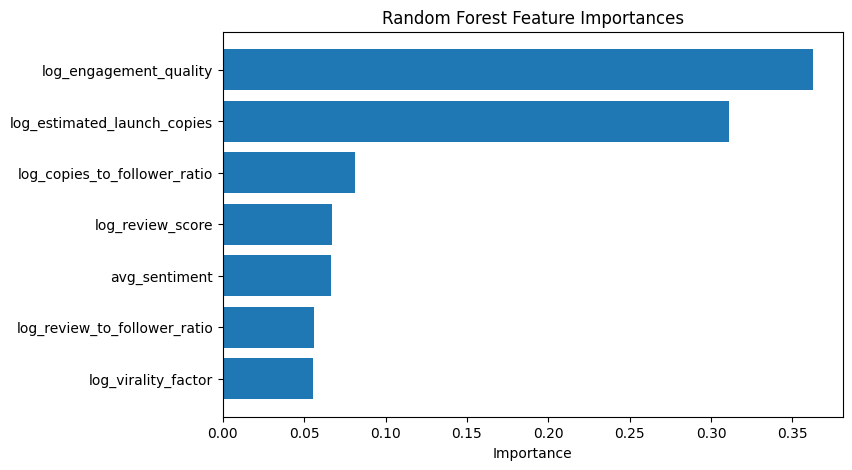

In [705]:
importances = random_forest_cv.best_estimator_.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values(by='importance', ascending=False)


print(feature_importance_df)

# Optional: plot
plt.figure(figsize=(8,5))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel("Importance")
plt.title("Random Forest Feature Importances")
plt.gca().invert_yaxis()
plt.show()